# Red bayesiana - Titanic

Objetivo: aprender estructura probabilistica y evaluar clasificacion.

## 1) Librerias

In [5]:
!pip install pandas matplotlib seaborn scikit-learn pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 2.0 MB/s  0:00:002.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 3.1 MB/s  0:00:003.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 1.4 MB/s  0:00:00m 2.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 3.0 MB/s  0:00:26 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 2.8 MB/s  0:00:02m 2.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 3.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 3.3 MB/s  0:00:00m 3.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 3.3 MB/s  0:00:03 3.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [pgmpy]m━━ 13/14 [pgmpy]pl]ls]]]


In [6]:
# Datos
import pandas as pd


In [7]:
# Calculo numerico
import numpy as np


In [123]:
# Estructura de red
from pgmpy.estimators import HillClimbSearch, ExpertKnowledge


In [95]:
# Modelo de red
from pgmpy.models import DiscreteBayesianNetwork


In [11]:
# Ajuste de parametros
from pgmpy.estimators import MaximumLikelihoodEstimator


In [12]:
# Metricas
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report


## 2) Cargar datos

In [13]:
# Leer archivo
titanic = pd.read_csv("titanic.csv")


In [41]:
# Tipos de columnas
titanic.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    category
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    str     
 11  Embarked     889 non-null    str     
dtypes: category(2), float64(2), int64(4), str(4)
memory usage: 71.5 KB


## 3) Preparar datos

In [77]:
# Convertir tipos
titanic["Survived"] = titanic["Survived"].astype(int)


In [78]:
# Convertir tipos
titanic["Sex"] = titanic["Sex"].astype("category")


In [79]:
# Convertir tipos
titanic["Pclass"] = titanic["Pclass"].astype("category")


In [80]:
# Eliminar faltantes clave
datos_modelo = titanic.dropna(subset=["Age", "Embarked"])


In [81]:
# Seleccionar variables
datos_modelo = datos_modelo[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]


In [82]:
# Discretizar edad
datos_modelo["Age_disc"] = pd.cut(datos_modelo["Age"], bins=[0, 18, 35, 60, 100], labels=["Joven", "Adulto", "Maduro", "Mayor"], include_lowest=True)


In [83]:
# Discretizar tarifa
datos_modelo["Fare_disc"] = pd.qcut(datos_modelo["Fare"], q=4, labels=["Bajo", "Medio", "Alto", "MuyAlto"], duplicates="drop")


In [84]:
# Discretizar SibSp
datos_modelo["SibSp_disc"] = np.where(datos_modelo["SibSp"] == 0, "Ninguno", np.where(datos_modelo["SibSp"] <= 2, "Pocos", "Muchos"))


In [85]:
# Discretizar Parch
datos_modelo["Parch_disc"] = np.where(datos_modelo["Parch"] == 0, "Ninguno", np.where(datos_modelo["Parch"] <= 2, "Pocos", "Muchos"))


In [86]:
# Armar dataset discreto
datos_bn = datos_modelo[["Survived", "Pclass", "Sex", "Age_disc", "SibSp_disc", "Parch_disc", "Fare_disc", "Embarked"]].copy()


In [87]:
# Convertir todo a texto/categoria
for col in datos_bn.columns:
    datos_bn[col] = datos_bn[col].astype("category")


## 4) Separar entrenamiento y prueba (80/20)

In [88]:
# Muestreo reproducible
np.random.seed(123)


In [89]:
# Indices
indices = np.random.choice(datos_bn.index, size=int(0.8 * len(datos_bn)), replace=False)


In [90]:
# Conjuntos discretos
entrenamiento_bn = datos_bn.loc[indices].copy()
prueba_bn = datos_bn.drop(indices).copy()


In [91]:
entrenamiento_bn

,Survived,Pclass,Sex,Age_disc,SibSp_disc,Parch_disc,Fare_disc,Embarked
509,1,3,male,Adulto,Ninguno,Ninguno,MuyAlto,S
640,0,3,male,Adulto,Ninguno,Ninguno,Bajo,S
537,1,1,female,Adulto,Ninguno,Ninguno,MuyAlto,C
526,1,2,female,Maduro,Ninguno,Ninguno,Medio,S
262,0,1,male,Maduro,Pocos,Pocos,MuyAlto,S
...,...,...,...,...,...,...,...,...
597,0,3,male,Maduro,Ninguno,Ninguno,Bajo,S
555,0,1,male,Mayor,Ninguno,Ninguno,Alto,S
729,0,3,female,Adulto,Pocos,Ninguno,Bajo,S
321,0,3,male,Adulto,Ninguno,Ninguno,Bajo,S


In [92]:
# Conjuntos originales para metricas
entrenamiento = datos_modelo.loc[indices].copy()
prueba = datos_modelo.drop(indices).copy()


## 5) Aprender estructura y ajustar red

In [127]:
# Buscar estructura
busqueda = HillClimbSearch(entrenamiento_bn)

ek = ExpertKnowledge(
    forbidden_edges=[
        ("Survived", "Sex"),
        ("Survived", "Pclass"),
        ("Survived", "Embarked"),
        ("Survived", "Fare_disc"),
        ("Survived", "SibSp_disc"),
        ("Survived", "Parch_disc"),
        ("Survived", "Age_disc"),

        ("Fare_disc", "Pclass"),
        ("Embarked", "Pclass"),
        ("Sex", "Pclass"),
        ("SibSp_disc", "Pclass"),
        ("Parch_disc", "Pclass"),
    ],
)

estructura = busqueda.estimate(scoring_method="bic-d", expert_knowledge=ek)


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age_disc': 'O', 'SibSp_disc': 'C', 'Parch_disc': 'C', 'Fare_disc': 'O', 'Embarked': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age_disc': 'O', 'SibSp_disc': 'C', 'Parch_disc': 'C', 'Fare_disc': 'O', 'Embarked': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age_disc': 'O', 'SibSp_disc': 'C', 'Parch_disc': 'C', 'Fare_disc': 'O', 'Embarked': 'C'}
  0%|          | 9/1000000 [00:00<2:45:55, 100.45it/s]


Learned edges: [('Pclass', 'Fare_disc'), ('Pclass', 'Survived'), ('Pclass', 'Embarked'), ('Pclass', 'SibSp_disc'), ('Sex', 'Survived'), ('SibSp_disc', 'Fare_disc'), ('Parch_disc', 'Age_disc'), ('Fare_disc', 'Parch_disc'), ('Fare_disc', 'Sex')]


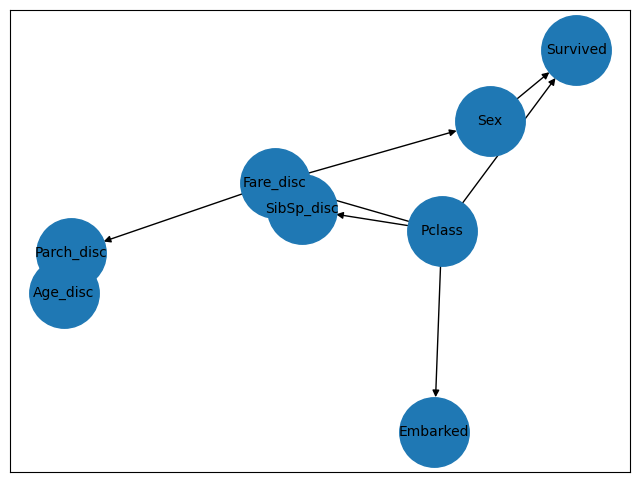

In [128]:
print("Learned edges:", list(estructura.edges()))

# convertir a networkx explícitamente
G = nx.DiGraph()
G.add_nodes_from(estructura.nodes())
G.add_edges_from(estructura.edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    arrows=True,
    node_size=2500,
    font_size=10
)

In [129]:
# Crear modelo de red
modelo = DiscreteBayesianNetwork(estructura.edges())


In [130]:
# Ajustar parametros
modelo.fit(entrenamiento_bn, estimator=MaximumLikelihoodEstimator)


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Survived': 'C', 'Pclass': 'C', 'Sex': 'C', 'Age_disc': 'O', 'SibSp_disc': 'C', 'Parch_disc': 'C', 'Fare_disc': 'O', 'Embarked': 'C'}


## 6) Predecir

In [131]:
# Prediccion entrenamiento
pred_train_df = modelo.predict(entrenamiento_bn.drop(columns=["Survived"]))
pred_train = pred_train_df["Survived"].astype(int)


100%|██████████| 190/190 [00:04<00:00, 46.38it/s]


In [132]:
# Prediccion prueba
pred_test_df = modelo.predict(prueba_bn.drop(columns=["Survived"]))
pred_test = pred_test_df["Survived"].astype(int)


100%|██████████| 86/86 [00:00<00:00, 1312.81it/s]


## 7) Evaluacion

In [133]:
# Matriz de confusion entrenamiento
cm = confusion_matrix(entrenamiento["Survived"], pred_train)
pd.DataFrame(cm, index=['Real_0', 'Real_1'], columns=['Pred_0', 'Pred_1'])


,Pred_0,Pred_1
Real_0,271,70
Real_1,172,56


In [134]:
# Reporte de clasificacion
print(classification_report(entrenamiento["Survived"], pred_train, digits=4, zero_division=0))


              precision    recall  f1-score   support

           0     0.6117    0.7947    0.6913       341
           1     0.4444    0.2456    0.3164       228

    accuracy                         0.5747       569
   macro avg     0.5281    0.5202    0.5039       569
weighted avg     0.5447    0.5747    0.5411       569



In [135]:
# Matriz de confusion prueba
cm = confusion_matrix(prueba["Survived"], pred_test)
pd.DataFrame(cm, index=['Real_0', 'Real_1'], columns=['Pred_0', 'Pred_1'])


,Pred_0,Pred_1
Real_0,81,2
Real_1,31,29


In [136]:
# Reporte de clasificacion
print(classification_report(prueba["Survived"], pred_test, digits=4, zero_division=0))


              precision    recall  f1-score   support

           0     0.7232    0.9759    0.8308        83
           1     0.9355    0.4833    0.6374        60

    accuracy                         0.7692       143
   macro avg     0.8293    0.7296    0.7341       143
weighted avg     0.8123    0.7692    0.7496       143



In [137]:
# Accuracy entrenamiento
accuracy_score(entrenamiento["Survived"], pred_train)


0.5746924428822495

In [138]:
# Precision entrenamiento
precision_score(entrenamiento["Survived"], pred_train, zero_division=0)


0.4444444444444444

In [139]:
# Recall entrenamiento
recall_score(entrenamiento["Survived"], pred_train, zero_division=0)


0.24561403508771928

In [140]:
# Accuracy prueba
accuracy_score(prueba["Survived"], pred_test)


0.7692307692307693

In [141]:
# Precision prueba
precision_score(prueba["Survived"], pred_test, zero_division=0)


0.9354838709677419

In [142]:
# Recall prueba
recall_score(prueba["Survived"], pred_test, zero_division=0)


0.48333333333333334

In [143]:
# Tabla resumen
resumen_metricas = pd.DataFrame({
    "Metrica": ["Accuracy", "Precision", "Recall"],
    "Entrenamiento": [
        accuracy_score(entrenamiento["Survived"], pred_train),
        precision_score(entrenamiento["Survived"], pred_train, zero_division=0),
        recall_score(entrenamiento["Survived"], pred_train, zero_division=0),
    ],
    "Prueba": [
        accuracy_score(prueba["Survived"], pred_test),
        precision_score(prueba["Survived"], pred_test, zero_division=0),
        recall_score(prueba["Survived"], pred_test, zero_division=0),
    ]
})
resumen_metricas


,Metrica,Entrenamiento,Prueba
0,Accuracy,0.574692,0.769231
1,Precision,0.444444,0.935484
2,Recall,0.245614,0.483333


> Nota: este cuaderno requiere `pgmpy` instalado.